# CardioIA – Fase 2 – Parte 2: Classificador de risco (triagem)
Classifica frases de sintomas em **alto risco** ou **baixo risco** usando **TF-IDF + Regressão Logística**.

A base de frases foi gerada a partir do dataset da **Fase 1** (`../dados_fase1/dados_pacientes_cardiacos.csv`) pelo script `gerar_base_risco.py`: cada paciente virou uma frase e o risco "Alto"/"Baixo" virou o rótulo (pacientes "Moderado" ficaram de fora).

> Projeto acadêmico: o modelo é um protótipo treinado com poucos dados simulados e **não substitui avaliação médica**.

## 1. Importações e leitura da base

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

df = pd.read_csv("base_risco.csv")
print(df.shape)
print(df["situacao"].value_counts())
df.head()

(69, 2)
situacao
baixo risco    51
alto risco     18
Name: count, dtype: int64


,frase,situacao
0,"Sou homem, tenho pressão alta, fumo, tenho his...",alto risco
1,"Sou mulher, tenho mais de 55 anos e sinto palp...",baixo risco
2,Sou homem e sinto falta de ar.,baixo risco
3,"Sou mulher, fumo e sinto falta de ar.",baixo risco
4,"Sou homem, tenho mais de 55 anos e sinto palpi...",baixo risco


## 2. Separação em treino e teste
Divisão de 75%/25% com `stratify` para manter a proporção entre as classes.

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    df["frase"], df["situacao"],
    test_size=0.25, random_state=42, stratify=df["situacao"]
)
print("Treino:", len(X_train), "| Teste:", len(X_test))

Treino: 51 | Teste: 18


## 3. TF-IDF
Transforma cada frase em um vetor numérico. O vetorizador é ajustado **apenas no treino** para evitar vazamento de dados. Usamos unigramas e bigramas para capturar expressões como "dor no peito".

In [3]:
vetorizador = TfidfVectorizer(lowercase=True, strip_accents="unicode", ngram_range=(1, 2))
X_train_tfidf = vetorizador.fit_transform(X_train)
X_test_tfidf = vetorizador.transform(X_test)
print("Formato da matriz de treino:", X_train_tfidf.shape)

Formato da matriz de treino: (51, 94)


## 4. Treinamento do modelo (Regressão Logística)

In [4]:
# class_weight='balanced' compensa o desbalanceamento (poucos casos de alto risco)
modelo = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
modelo.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

## 5. Avaliação

Acurácia: 0.889

              precision    recall  f1-score   support

  alto risco       0.71      1.00      0.83         5
 baixo risco       1.00      0.85      0.92        13

    accuracy                           0.89        18
   macro avg       0.86      0.92      0.88        18
weighted avg       0.92      0.89      0.89        18



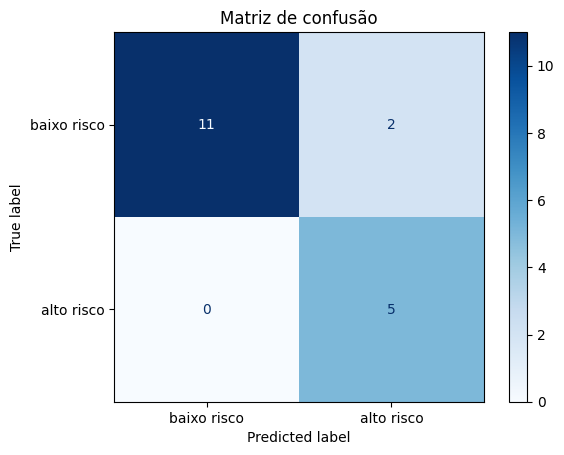

In [5]:
y_pred = modelo.predict(X_test_tfidf)
print("Acurácia:", round(accuracy_score(y_test, y_pred), 3))
print()
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=["baixo risco", "alto risco"])
ConfusionMatrixDisplay(cm, display_labels=["baixo risco", "alto risco"]).plot(cmap="Blues")
plt.title("Matriz de confusão")
plt.show()

**Como ler:** em triagem clínica, o pior erro é o **falso negativo** (paciente de alto risco classificado como baixo risco). Por isso, além da acurácia, vale olhar o *recall* da classe "alto risco".

## 6. Frases que o modelo errou no teste

In [6]:
erros = pd.DataFrame({"frase": X_test.values, "real": y_test.values, "previsto": y_pred})
erros[erros["real"] != erros["previsto"]]

,frase,real,previsto
5,Sou homem e sinto dor no peito.,baixo risco,alto risco
9,Sou mulher e sinto dor no peito.,baixo risco,alto risco


## 7. Palavras que mais influenciam a decisão
Ajuda a enxergar padrões e possíveis distorções aprendidas.

In [7]:
palavras = np.array(vetorizador.get_feature_names_out())
coef = modelo.coef_[0]
classes = modelo.classes_
# coef positivo -> classes[1]; negativo -> classes[0]
idx = np.argsort(coef)
print(f"Mais associadas a '{classes[0]}':", list(palavras[idx[:10]]))
print(f"Mais associadas a '{classes[1]}':", list(palavras[idx[-10:]][::-1]))

Mais associadas a 'alto risco': ['tenho', 'fumo tenho', 'dor', 'dor no', 'no', 'peito', 'no peito', 'sinto dor', 'fumo', 'familia tenho']
Mais associadas a 'baixo risco': ['sinto palpitacoes', 'mulher tenho', 'sinto cansaco', 'sou', 'mulher', 'sou mulher', 'falta de', 'falta', 'de ar', 'ar']


## 8. Testando frases novas, incluindo casos difíceis
Algumas frases no mesmo estilo da base e outras em estilo diferente ou com negação, para ver os limites do modelo.

In [8]:
novas = [
    "Sou homem, fumo, tenho diabetes e sinto dor no peito.",                      # no estilo da base; esperado: alto
    "Sou mulher, tenho pressão alta, tenho colesterol alto, fumo e tenho diabetes.",  # fatores de risco, sem sintomas
    "Sou mulher e sinto dor no peito e falta de ar.",                             # sintomas graves, sem fatores de risco
    "Sou homem e não tenho sintomas nem fatores de risco.",                       # esperado: baixo
    "Sinto uma dor forte no peito e suor frio há vinte minutos.",                 # estilo diferente da base
    "Não tenho dor no peito nem falta de ar.",                                    # negação
]
probs = modelo.predict_proba(vetorizador.transform(novas))
i_alto = list(modelo.classes_).index("alto risco")
for frase, p, pred in zip(novas, probs, modelo.predict(vetorizador.transform(novas))):
    print(f"{pred:12s} (P alto risco = {p[i_alto]:.2f}) <- {frase}")

alto risco   (P alto risco = 0.67) <- Sou homem, fumo, tenho diabetes e sinto dor no peito.
alto risco   (P alto risco = 0.60) <- Sou mulher, tenho pressão alta, tenho colesterol alto, fumo e tenho diabetes.
baixo risco  (P alto risco = 0.37) <- Sou mulher e sinto dor no peito e falta de ar.
baixo risco  (P alto risco = 0.19) <- Sou homem e não tenho sintomas nem fatores de risco.
alto risco   (P alto risco = 0.60) <- Sinto uma dor forte no peito e suor frio há vinte minutos.
baixo risco  (P alto risco = 0.40) <- Não tenho dor no peito nem falta de ar.


## 9. Análise crítica (viés e limitações)
- **Base pequena (69 frases) e desbalanceada:** são 51 frases de baixo risco e só 18 de alto risco, e o teste tem apenas 18 frases (5 de alto risco). A acurácia (~89%) muda bastante se mudarmos a divisão. Usamos `class_weight="balanced"` para o modelo não ignorar a classe rara.
- **Rótulo vem de uma regra simplificada, não de um médico:** na Fase 1 o risco foi calculado somando pontos (idade, pressão, colesterol, fumo, diabetes, dor no peito, histórico familiar). Por isso um paciente que só sente dor no peito fica como "baixo risco" na base, e o modelo "errou" ao chamá-lo de alto risco. Nesse caso o modelo parece mais coerente com a clínica do que o rótulo.
- **Sintomas graves com pouco peso:** "Sou mulher e sinto dor no peito e falta de ar" é classificada como baixo risco (P de alto risco = 0,37). Em triagem real, esse seria um falso negativo perigoso, o pior tipo de erro.
- **Atalhos nas palavras:** as palavras mais associadas ao baixo risco incluem "mulher" e "sou mulher". Isso é um possível **viés de gênero** aprendido por acaso da base pequena, e não uma relação real.
- **Frases em estilo diferente:** o modelo só viu frases no formato da base (sempre começando com "Sou homem/mulher"). Frases livres, com negação ou vocabulário novo, ficam com probabilidade perto de 0,5, ou seja, o modelo fica "em dúvida" porque o TF-IDF não entende o sentido.
- **Governança de dados:** os dados são simulados (não são pessoas reais) e geram frases todas no mesmo padrão. Em um sistema real seriam necessários dados reais anonimizados (LGPD), rótulos revisados por médicos e avaliação separada por grupos (sexo, idade, escolaridade).
- **Uso responsável:** o sistema é só apoio à decisão. Quem decide é o profissional de saúde.